# Import

* pandas: 데이터 정제를 위해 사용

* matplotlib.pyplot: plot, bar와 같은 그래프를 그리기 위해 사용

* matplotlib: 그래프를 그리기 위한 환경을 설정

In [3]:
#import

import pandas as pd

import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic', 'Hiragino Sans'
# AppleGothic -> 한국어 지원
# Hiragino Sans -> 일본어 지원

matplotlib.rcParams['font.size'] = 10
# 글자 크기 설정

matplotlib.rcParams['axes.unicode_minus'] = False
# 한글의 마이너스 부호(-)가 깨지는 것을 방지

In [4]:
# 예시용 데이터
data = {
    "이름": ["민수", "지영", "철수"],
    "나이": [20, 21, 22],
    "점수": [85, 92, 78]
}

# Pandas

## 1. 객체 다루기

In [5]:
df = pd.Series([1, 2, 3])
# 1차원 배열 객체 생성
# index = []  | 요소의 인덱스를 설정

df = pd.DataFrame(data)
# DataFrame 객체 생성
# index = []  | 행(index)의 이름 지정
# columns = []  | 열(column)의 이름 지정

df

,이름,나이,점수
0,민수,20,85
1,지영,21,92
2,철수,22,78


## 2. 호출

In [90]:
df['이름']
# 해당 열을 호출
# 두 개 이상의 열을 호출할 때는 이중 대괄호 사용  ex) [['이름', '점수']]

df['학년'] = [1, 2, 3]
# 새로운 column을 생성하여 객체에 저장함

df.columns
# column의 이름들을 호출
# [번호]  | 인덱스 번호를 통해 해당 column의 이름을 가져옴

df.index
# index 이름들을 출력
# [번호]  | 인덱스 번호를 통해 해당 index의 이름을 가져옴

df.index.name = '번호'
# index 라인의 이름을 지정함
# df.index.name  | 단독 사용시 index 라인의 이름을 가져옴

df.head()
# 기본 5개의 값을 위에서부터 가져옴
# 숫자 지정 가능

df.tail()
# 기본 5개의 값을 아래서부터 가져옴
# 숫자 지정 가능

df.values
# df 객체의 값을 배열(numpy) 형태로 가져옴

df.shape
# (row, column)의 형태로 갯수를 가져옴

df.loc[0, '이름']
# [row, column]의 형태와 같이 '문자'를 주고 호출
# 단, index가 설정되어 있지 않은 경우, ''으로 감싸지 않음 ex) index= [0, 1, 2...]
# 형태 -> [0 : 1, '이름' : '나이']  or  [[0, 1], ['이름', '나이']]

df.iloc[0, 0]
# [row, column]의 형태로 정수(index와 column 번호)를 넣어 호출
# 형태 -> [ : , 1], [0 : 2, 1 : 1]

df = df[['이름', '학년', '나이', '점수']]
# df.columns의 순서를 바꿈

## 3. 명령어

In [13]:
df.loc[3] = ['영준', 25, 100]
# DataFrame 객체에 새로운 행 추가 방식
# [] 안에 없는 index를 적을 시 새로운 행 생성

df.reset_index()
# index를 0부터 시작해서 새로 생성, 기존의 index는 새로운 열로 만듬
# drop = True  | 기존의 index를 삭제 
# inplace = True  | 원본 df에 반영함(이하 언급하지 않음)

df.set_index('이름')
# 기존 index를 삭제하고 해당 열을 index로 설정
# drop = False | index로 설정할 열을 버리지 않음
# inplace = True  

df.sort_index()
# index를 기준으로 오름차순 정렬
# ascending = False  | 내림차순으로 정렬
# inplace = True

df.describe()
# 데이터의 기본 통계를 보여줌. 개별 호출 가능 ex) df.count
# count -> 데이터 개수
# mean -> 평균값
# std -> 표준편차
# min -> 최솟값
# max -> 최댓값
# unique -> 고유값 개수
# top -> 가장 많이 나온 값
# freq -> 가장 많이 나온 횟수

df.fillna('replace')
# df 전체 데이터 중 NaN 데이터에 대해 데이터를 대체함
# inplace = True

df.dropna(axis='index', how='any')
# NaN이 있는 데이터를 삭제함. 기본값은 위와 같음
# axis = 'index'(NaN이 있는 행을 삭제) or 'columns'(NaN이 있는 열을 삭제)
# how = 'any'(NaN이 하나라도 있으면 삭제) or 'all'(전부 NaN이면 삭제)
# inplace = True

df.sort_values('나이')
# 해당하는 column을 기준으로 오름차순 정렬(행 전체가 같이 움직임)
# ascending = False  | 내림차순 정렬

df['이름'].replace({'민수':'수민'})
# 해당 column에서 정확히 일치하는 값만을 찾아 바꿈  민수 -> 수민
# inplace = True

df['이름'].str.replace('민', '빈')
# 해당 column을 전부 문자열로 바꾸고 해당하는 글자를 바꿈
# inplace = True

df.drop(columns=['이름'])
# 해당하는 값을 삭제함
# columns = ['']  | 해당하는 column을 삭제
# index = ''  | 해당하는 index를 삭제
#inplace = True

df.groupby('이름')
# 해당하는 column에서 같은 값을 가진 것 끼리 하나로 묶어 작업을 수행
# .mean()  | 묶인 데이터들 끼리의 평균을 구함
# .get_group('점수')  | 그룹별로 해당하는 column의 데이터를 가져옴

## 4. 파일

In [ ]:
# save

df.to_csv('test_csv.csv', encoding='utf-8-sig')
# csv 형태로 객체 파일 생성
# index = False  | index를 저장하지 않고 파일을 저장함

df.to_csv('test_txt.txt', sep='\t')
# txt 형태로 객체 파일 생성
# sep  | 지정한 구분자를 통해 요소를 구분함
# index = False

df.to_excel('test.xlsx')
# Excel 형태로 객체 파일 생성
# index = False


# read

df = pd.read_csv('test_csv.csv')
# csv 형태로 파일을 불러와 df 객체로 저장
# skiprows = n  | n개의 행을 건너뜀 (그 다음 행은 head로 인식됨)
# index_col = n  | n번 째 column이 index로 설정됨 (지정하지 않으면 기본 index 생성)
# nrows = n  | head를 제외한 n개의 행을 불러옴
# usecols = ['이름', '나이']  | 해당하는 columns만 가져옴

df = pd.read_csv('test_txt.txt', sep='\t')
# txt 형태로 파일을 불러와 df 객체에 저장
# skiprows = n  | n개의 행을 건너뜀 (그 다음 행은 head로 인식됨)
# index_col = n  | n번 째 column이 index로 설정됨 (지정하지 않으면 기본 index 생성)
# nrows = n  | head를 제외한 n개의 행을 불러옴
# usecols = ['이름', '나이']  | 해당하는 columns만 가져옴

df = pd.read_excel('text_excel.xlsx')
# Excel 형태로 파일을 불러와 df 객체에 저장
# skiprows = n  | n개의 행을 건너뜀 (그 다음 행은 head로 인식됨)
# index_col = n  | n번 째 column이 index로 설정됨 (지정하지 않으면 기본 index 생성)
# nrows = n  | head를 제외한 n개의 행을 불러옴
# usecols = ''  | 엑셀에 해당하는 columns만 가져옴 ex) 'A:B, D'

## 5. 필터링
True or False로 반환하는 Class

In [92]:
df['이름'].str.startswith('민')
# 해당하는 column을 str로 변환 후, 'target' 문자로 시작하는지 확인

df['이름'].str.endswith('수')
# 해당하는 column을 str로 변환 후, 'target' 문자로 끝나는지 확인

df['이름'].isin(['민수'])
# 해당하는 column에 [] 요소가 있는지 확인

df['이름'].notnull()
# 해당 column에 NaN이 있는지 확인.  없으면 -> True

번호
0    True
1    True
2    True
Name: 이름, dtype: bool

## 6. 함수

In [82]:
# 연습용 함수 정의
def addit(df):
    return df + 10


df['점수'] = df['점수'].apply(addit)
# apply()는 각 요소들을 한 번 씩 써서 값을 인수로 보내 함수를 호출함

# Matplotlib

In [154]:
# 예시 
x = [1, 2, 3]
y = [2, 4, 8]
z = [3, 5, 9]

## 1. 명령어

In [ ]:
plt.show()
# 실행시 나오는 명령어 제거

plt.savefig('name.png')
# 그래프를 저장
# dpi = n  | 그래프 해상도 설정

plt.title('name')
# 그래프의 제목 설정
# fontdict = {'size' : 20}  | 폰트 사이즈 설정

plt.xlabel('x축')
# x축의 범례 추가
# color = 'r'  
# loc = 'right'  | 범례의 위치 설정     or left, center
# rotation = 90  | 범례 각도 설정

plt.ylabel('y축')
# y축의 범례 추가
# color = 'r'
# loc = 'top'     or center, bottom
# rotation = 0

plt.xticks([1, 2, 3], [3, 2, 1])
# x에 표시되는 값을 지정. 첫 번째 리스트는 위치, 두 번째 리스트는 표시값을 지정
# 만약 값만 지정할 경우, 리스트 하나만으로도 파라메터 지정 가능
# rotation = 45

plt.yticks([2, 4, 8], [8, 4, 2])
# y에 표시되는 값을 지정. 첫 번째 리스트는 위치, 두 번째 리스트는 표시값을 지정
# 만약 값만 지정할 경우, 리스트 하나만으로도 파라메터 지정 가능
# rotation = 45

plt.legend()
# 범례를 추가함
# loc = (0, 1)  | 범례 표시 좌표
# ncol = n  | 행으로 몇 개의 범례를 표시할지 지정
# title = ''  | 범례의 제목 표시

plt.figure(figsize=(10,5), dpi=200)
# (x, y)의 형태로 그래프 크기를 조정하고 해상도를 설정
# facecolor = 'y'  | 그래프의 마진 색 설정

plt.text(x[0], y[0], '(0,0)')
# 그래프의 x, y 위치에 텍스트를 지정. 주로 반복문을 통해 사용
# ha = 'center'  | 텍스트의 수평 위치를 조정

plt.grid()
# 그래프 격자 생성
# axis = 'x'  | x축 격자만 생성     or y
# color = 'r'
# alpha = 1
# linestyle = ':'
# linwidth = n  

plt.ylim(0, 10)
# y의 최소, 최대 지정

plt.xlim(0, 10)
# x의 최소, 최대 지정

## 2. 여러 그래프(Subplot)

(0.0, 8.0)

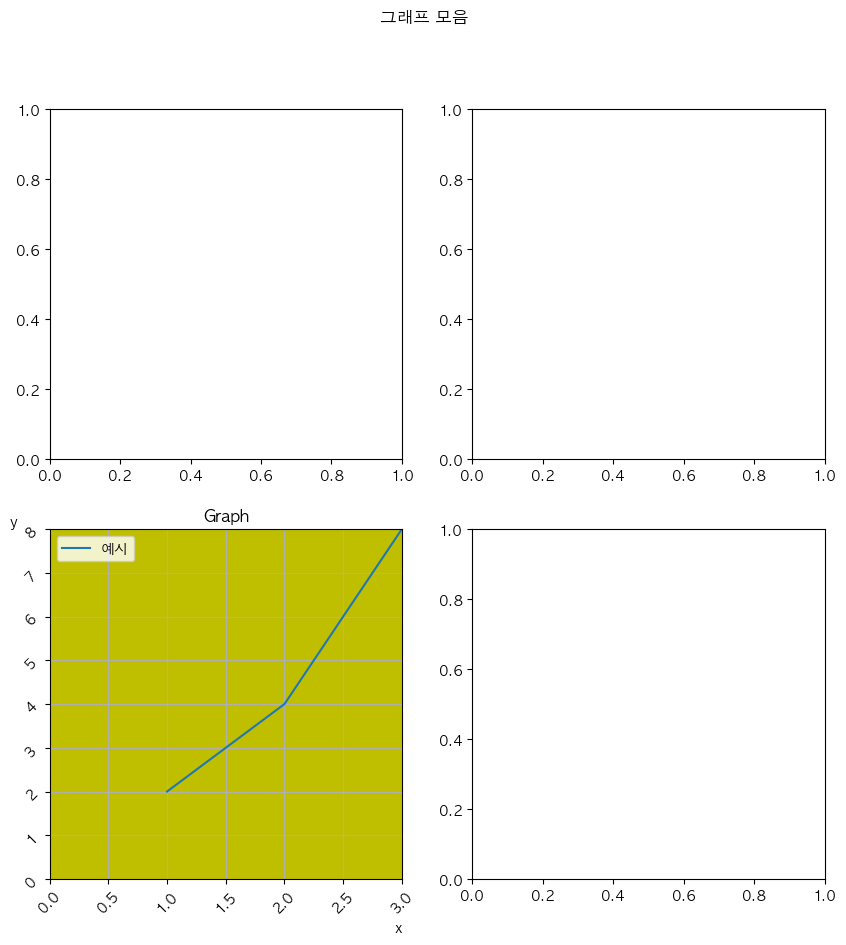

In [155]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# (행, 열)의 형태로 여러 그래프를 생성
# fig  | 전체 그래프의 창
# axs  | 각 그래프의 공간     ex) axs[1,0]과 같은 형태로 접근

fig.suptitle('그래프 모음')
# 전체 그래프의 대표 이름 설정

axs[1,0].plot(x, y, label='예시')
# 2행 1열 위치에 그래프를 그림

axs[1,0].set_title('Graph')
# 해당 그래프의 제목을 설정

axs[1,0].legend()
# 범례는 개별적으로 호출

axs[1,0].set_xlabel('x', loc='right', rotation = 0)
# 개별 그래프의 xlabel 설정

axs[1,0].set_ylabel('y', loc='top', rotation = 0)
# 개별 그래프의 ylabel 설정

axs[1,0].set_facecolor('y')
# 개별 그래프의 배경색 지정

axs[1,0].grid()
# 개별 그래프의 격자 생성

axs[1,0].tick_params(rotation = 45)
# 개별 그래프의 x축과 y축의 각도를 회전
# axis = 'x'  | x축에만 적용     or 'y'

axs[1,0].set_xlim(0,3)

axs[1,0].set_ylim(0,8)

## 3. 꺾은선 그래프(plot)

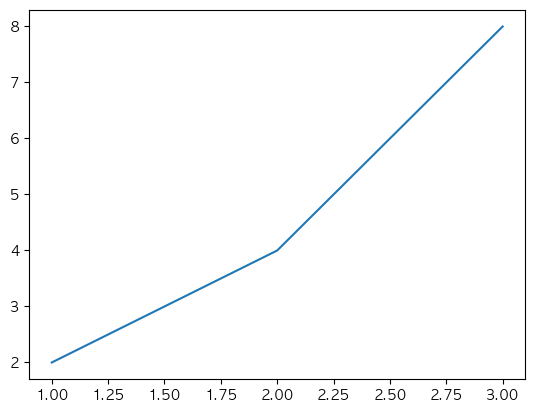

In [99]:
plt.plot(x, y)
# label = '설명'  | 그래프에 대한 범례 표시
# linewidth = n  | 그래프의 두께 설정
# marker = 'o'  | 그래프 값 부분에 표시
# linestyle = '--'  | 그래프 스타일 지정     or ls
# markersize = n  | marker의 두께 설정     or ms
# markeredgecolor = 'r'  | marker의 테두리 색 지정     or mec
# markerfacecolor = 'y'  | marker의 내부 색 지정     or mfc
# alpha = 1  | 그래프의 투명도 조절

## 4. 막대 그래프

<BarContainer object of 3 artists>

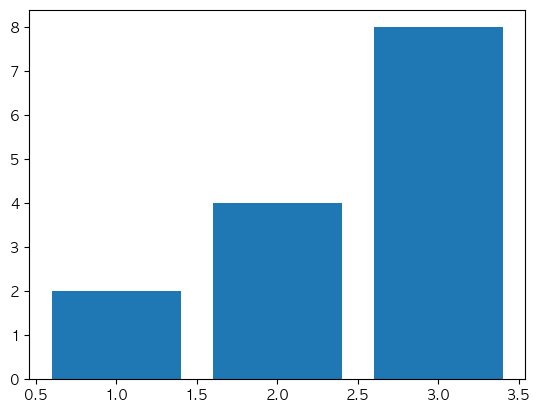

In [140]:
plt.bar(x, y)
# 막대 그래프 생성
# color = 'r'  or color = ['r', 'g', 'b']  
# alpha = 1
# width = 1
# plt.bar(x, y)[index].set_hatch('/')  | 그래프 무늬 설정
# bottom = z  | z만큼 올리고 다음부터 막대그래프를 누적함  * 사전에 z도 그래프에 그려져야 함, +로 누적 가능 ex) bottom = z + v

# import numpy as np
# index = np.arange(len(x))
# plt.bar(index - 0.25, y)  | arange() 함수를 이용하면 bar 함수 안에서 모든 요소들의 값을 조정할 수 있음

<BarContainer object of 3 artists>

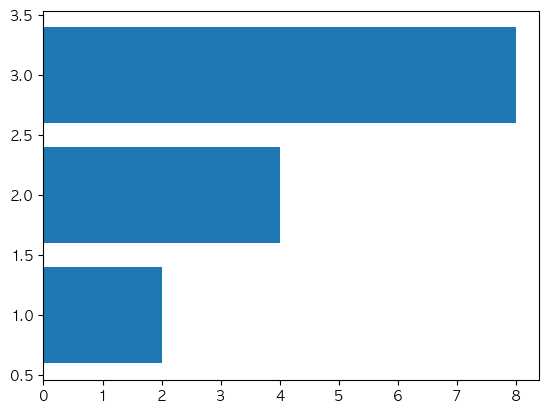

In [130]:
plt.barh(x, y)
# 가로 형태의 막대 그래프 생성
# 자동으로 x, y의 위치가 바뀜

# 5. 원 그래프

In [141]:
x = [1, 2, 3, 4]

([<matplotlib.patches.Wedge at 0x30fb951d0>,
 [Text(1.0461621649530053, 0.3399187029582827, ''),
  Text(0.33991865722907993, 1.0461621798113232, ''),
  Text(-1.046162235191088, 0.33991848678762215, ''),
  Text(0.33991884014588697, -1.0461621203780394, '')],
 [Text(0.5706339081561846, 0.18541020161360874, '10.0%'),
  Text(0.18541017667040724, 0.5706339162607217, '20.0%'),
  Text(-0.5706339464678661, 0.18541008370233936, '30.0%'),
  Text(0.18541027644321104, -0.5706338838425669, '40.0%')])

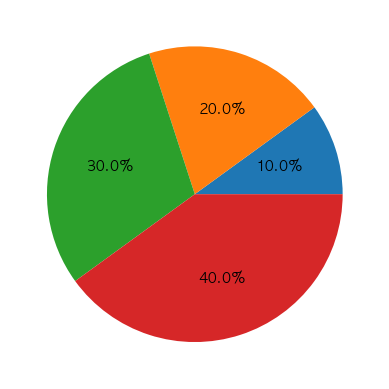

In [149]:
plt.pie(x, autopct='%.1f%%')
# 받은 값에 대해서 비율로 나타낸 원 그래프 생성
# labels = ['A', 'B', 'C', 'D']  | 각 조각에 이름을 붙임
# autopct = '%.1f%%'  | % -> 퍼센트 단위, .1f -> 소수점 1자리, %% -> %를 붙여서 표시
# explode=[0, 0, 0.1, 0]  | 특정 조각을 튀어나오게 함
# color = ['r', 'g', 'b', 'grey']
# startangle = 90  | 시작 각도 지정
# counterclock = False  | 시계방향으로 그림
# shadow=True  | 그림자 생성
# wedgeprops={'edgecolor':'black'}  | 테두리 생성

## 6. 산점도 그래프

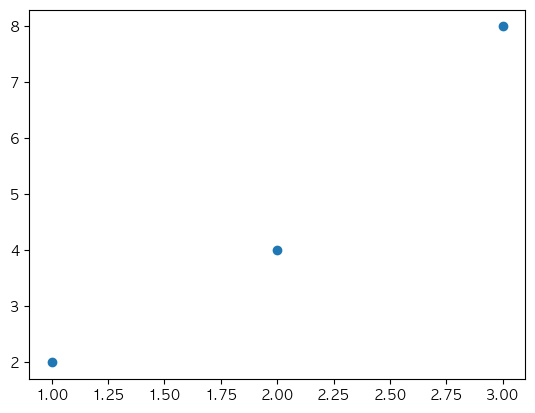

In [159]:
plt.scatter(x, y)
# s = n  | size 설정
# color = 'r'
# alpha = 1
# marker = 'o'